In [5]:
# ============================================
# CODSOFT DATA SCIENCE INTERNSHIP
# TASK 1 - TITANIC SURVIVAL PREDICTION
# PART 1 - IMPORTS & DATA LOADING
# ============================================

%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("="*60)
print("CODSOFT DATA SCIENCE INTERNSHIP")
print("TASK 1 : TITANIC SURVIVAL PREDICTION")
print("="*60)

# Load Dataset
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

print("\nFirst Five Rows")
print(df.head())

print("\nDataset Shape")
print(df.shape)

print("\nDataset Information")
print(df.info())

print("\nStatistical Summary")
print(df.describe())

print("\nMissing Values")
print(df.isnull().sum())

print("\nColumn Names")
print(df.columns)

# Select Useful Columns
data = df[['Pclass','Sex','Age','SibSp','Parch','Fare','Embarked','Survived']].copy()

# Fill Missing Values
age = SimpleImputer(strategy='median')
data['Age'] = age.fit_transform(data[['Age']])

embarked = SimpleImputer(strategy='most_frequent')
data['Embarked'] = embarked.fit_transform(data[['Embarked']]).ravel()

# Encode Categorical Variables
encoder = LabelEncoder()

data['Sex'] = encoder.fit_transform(data['Sex'])
data['Embarked'] = encoder.fit_transform(data['Embarked'])

print("\nProcessed Data")
print(data.head())

CODSOFT DATA SCIENCE INTERNSHIP
TASK 1 : TITANIC SURVIVAL PREDICTION

First Five Rows
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            11

In [6]:
# ============================================
# PART 2 - MODEL TRAINING & PREDICTION
# ============================================

# Features and Target
X = data.drop("Survived", axis=1)
y = data["Survived"]

print("="*60)
print("FEATURES")
print("="*60)
print(X.head())

print("\nTarget Values")
print(y.head())

# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("\nTraining Data Shape :", X_train.shape)
print("Testing Data Shape  :", X_test.shape)

# Create Random Forest Model
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train Model
model.fit(X_train, y_train)

print("\nModel Training Completed Successfully!")

# Prediction
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("\n" + "="*60)
print("MODEL PERFORMANCE")
print("="*60)

print(f"Accuracy : {accuracy:.4f}")
print(f"Accuracy Percentage : {accuracy*100:.2f}%")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix")
print(cm)

# Classification Report
print("\nClassification Report")
print(classification_report(y_test, y_pred))

# Display Actual vs Predicted
result = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

print("\nFirst 20 Predictions")
print(result.head(20))

FEATURES
   Pclass  Sex   Age  SibSp  Parch     Fare  Embarked
0       3    1  22.0      1      0   7.2500         2
1       1    0  38.0      1      0  71.2833         0
2       3    0  26.0      0      0   7.9250         2
3       1    0  35.0      1      0  53.1000         2
4       3    1  35.0      0      0   8.0500         2

Target Values
0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64

Training Data Shape : (712, 7)
Testing Data Shape  : (179, 7)

Model Training Completed Successfully!

MODEL PERFORMANCE
Accuracy : 0.8212
Accuracy Percentage : 82.12%

Confusion Matrix
[[92 13]
 [19 55]]

Classification Report
              precision    recall  f1-score   support

           0       0.83      0.88      0.85       105
           1       0.81      0.74      0.77        74

    accuracy                           0.82       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179


First 20 Predictions
    Actual


Generating Graphs...


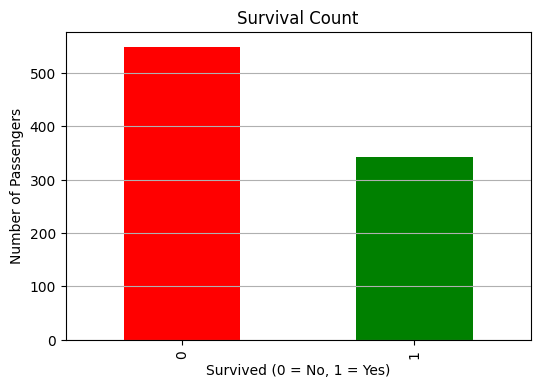

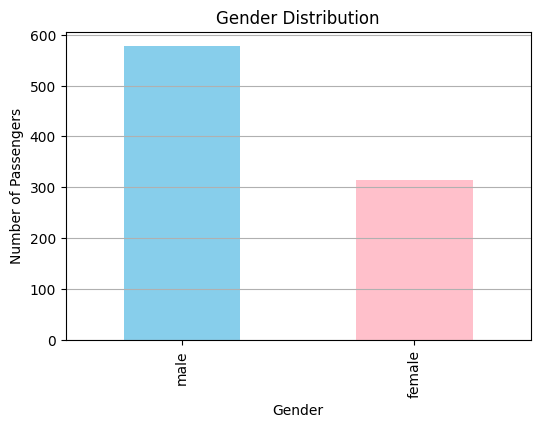

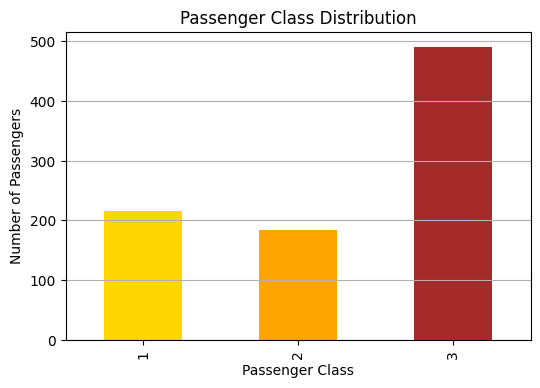

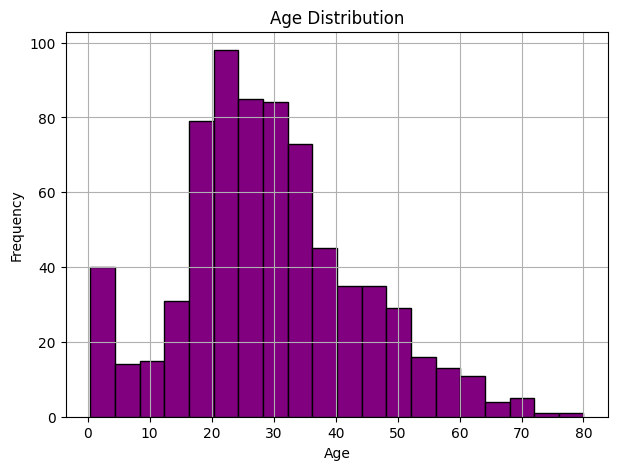

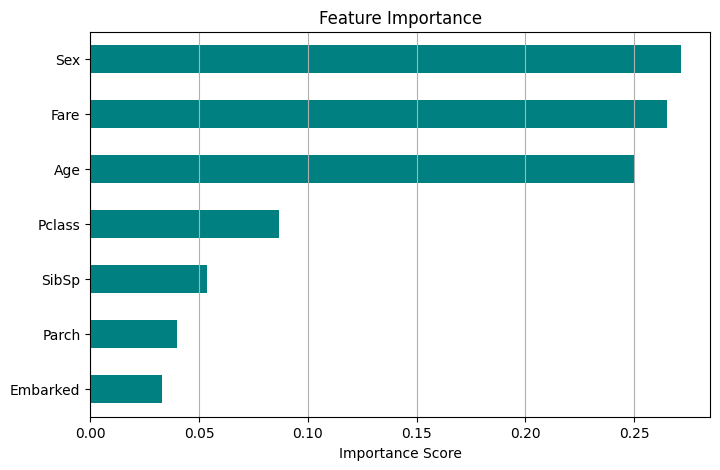

PROJECT CONCLUSION

Model Used : Random Forest Classifier

Accuracy Obtained : 82.12%

Conclusion:
1. The Titanic dataset was loaded successfully.
2. Missing values were handled using SimpleImputer.
3. Categorical variables were encoded using LabelEncoder.
4. The dataset was split into training and testing sets.
5. A Random Forest Classifier was trained.
6. The model predicted passenger survival with good accuracy.
7. Visualizations helped understand survival, gender,
   passenger class, age distribution, and feature importance.

CODSOFT TASK 1 COMPLETED SUCCESSFULLY.



In [7]:
# ============================================
# PART 3 - VISUALIZATION & CONCLUSION
# ============================================

print("\nGenerating Graphs...")

# -----------------------------
# Graph 1 - Survival Count
# -----------------------------
plt.figure(figsize=(6,4))
df["Survived"].value_counts().plot(kind="bar", color=["red","green"])
plt.title("Survival Count")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Number of Passengers")
plt.grid(axis="y")
plt.show()

# -----------------------------
# Graph 2 - Gender Distribution
# -----------------------------
plt.figure(figsize=(6,4))
df["Sex"].value_counts().plot(kind="bar", color=["skyblue","pink"])
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")
plt.grid(axis="y")
plt.show()

# -----------------------------
# Graph 3 - Passenger Class
# -----------------------------
plt.figure(figsize=(6,4))
df["Pclass"].value_counts().sort_index().plot(kind="bar", color=["gold","orange","brown"])
plt.title("Passenger Class Distribution")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")
plt.grid(axis="y")
plt.show()

# -----------------------------
# Graph 4 - Age Distribution
# -----------------------------
plt.figure(figsize=(7,5))
plt.hist(df["Age"].dropna(), bins=20, color="purple", edgecolor="black")
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

# -----------------------------
# Graph 5 - Feature Importance
# -----------------------------
importance = pd.Series(model.feature_importances_, index=X.columns)
importance = importance.sort_values()

plt.figure(figsize=(8,5))
importance.plot(kind="barh", color="teal")
plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.grid(axis="x")
plt.show()

# ============================================
# FINAL CONCLUSION
# ============================================

print("="*60)
print("PROJECT CONCLUSION")
print("="*60)

print(f"""
Model Used : Random Forest Classifier

Accuracy Obtained : {accuracy*100:.2f}%

Conclusion:
1. The Titanic dataset was loaded successfully.
2. Missing values were handled using SimpleImputer.
3. Categorical variables were encoded using LabelEncoder.
4. The dataset was split into training and testing sets.
5. A Random Forest Classifier was trained.
6. The model predicted passenger survival with good accuracy.
7. Visualizations helped understand survival, gender,
   passenger class, age distribution, and feature importance.

CODSOFT TASK 1 COMPLETED SUCCESSFULLY.
""")